# Final Project Amazon Reviews
### 12/12/2025
### Aren Mizuno
### Big Data and Cloud Computing 31013 IP03
#### Part 2

In [9]:
# Imports
from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.window import Window
from pyspark.sql.functions import col, split, monotonically_increasing_id
from pyspark.ml.feature import (
    RegexTokenizer,
    StopWordsRemover,
    CountVectorizer,
    IDF,
    HashingTF,
    MinHashLSH
)
from pyspark.ml.functions import vector_to_array
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re

In [10]:
# Paths
reviews_path = "gs://msca-bdp-data-open/final_project_reviews/reviews_parquet"
meta_path = "gs://msca-bdp-data-open/final_project_reviews/meta_parquet"
output_path = "gs://msca-bdp-students-bucket/shared_data/amizuno/amazon"

In [11]:
# Load data
df_reviews = spark.read.parquet(reviews_path)
df_meta = spark.read.parquet(meta_path)

In [12]:
# Drop rows where null for average_rating, main_category, parent_asin, price, rating_number
# Columns required to be non-null
required_cols = ["average_rating", "main_category", "parent_asin", "price", "rating_number"]

# Count before dropping
before = df_meta.count()

# Drop rows with NULL in any required column
df_meta = df_meta.dropna(subset=required_cols)

# Count after dropping
after = df_meta.count()

# Rows removed
dropped = before - after

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Rows dropped: {dropped}")

Rows before: 4320533
Rows after:  1716241
Rows dropped: 2604292


In [13]:
# Drop duplicates
df_reviews = df_reviews.dropDuplicates()

In [14]:
# Clean df_reviews
# Step 1 -- Convert
len_udf = F.udf(lambda s: 0 if not s else len(s), T.IntegerType())
df_reviews_conv = (
    df_reviews
    # Convert timestamp 
    .withColumn("review_date",
        F.to_date(
            F.from_unixtime((F.col("timestamp") / 1000).cast("long"))
        )
    )
)

# Step 2 -- Filter
df_reviews_filter = (
    df_reviews_conv
    # valid product
    .filter("asin IS NOT NULL AND parent_asin IS NOT NULL")
    
    # valid helpful vote
    .filter("helpful_vote >= 0")

    # valid rating range
    .filter("rating >= 1.0 AND rating <= 5.0")
    
    # valid date
    .filter("review_date IS NOT NULL")
    .filter(F.col("review_date") <= F.current_date())
    
    # valid user
    .filter("user_id IS NOT NULL")
        
    # valid verified purchase
    .filter("verified_purchase IS NOT NULL")
)

df_reviews_filter = df_reviews_filter.drop("asin", "helpful_vote", "timestamp", "verified_purchase")

In [15]:
# Clean df_meta
# Step 1 -- Convert into string
df_meta_conv = (
    df_meta
    # Clean string field
    .withColumn("main_category", F.regexp_replace(F.col("main_category").cast("string"), r"\s+", " "))
    
    # Convert price into int
    .withColumn("price", F.regexp_extract(F.col("price"), r"[\d\.]+", 0).cast("double"))
)

# Step 2 -- Filter
df_meta_filter = (
    df_meta_conv
    # valid avg rating
    .filter("average_rating >= 1.0 AND average_rating <= 5.0")
    
    # valid category
    .filter("main_category IS NOT NULL")
    
    # valid product
    .filter("parent_asin IS NOT NULL")
    
    # valid price
    .filter("price > 0")
    
    # valid rating_number
    .filter("rating_number >= 1")
)

df_meta_filter = df_meta_filter.drop("author", "bought_together", "categories", "description", "store", "subtitle", "title")

- How unique are the “title” and “review” values? Pick only ONE category of your choice, you may apply sampling if needed.
    - Are they mostly unique? Or are people usually just copy-pasting the same text?
    - You can use LSH to measure uniqueness / similarity
    - Visualize “review titles” and “review texts” duplication
    - Visualize “review titles” and “review texts” duplication for each of the top 5 products
    - Please note: this is not a topic modeling (LDA / LSA) – but text similarity analysis

In [16]:
df_joined = (
    df_reviews_filter.alias("r")
    .join(
        df_meta_filter.select("parent_asin", "main_category").alias("m"),
        on="parent_asin",
        how="inner"
    )
)

In [17]:
category = "Video Games"  

df_cat = (
    df_joined
    .filter(F.col("main_category") == category)
    .select("parent_asin", "title", "text")
    .sample(fraction=0.1, seed=42) 
)

### Text

In [18]:
# 1. CLEAN + TOKENIZE (TEXT)
df_text = df_cat.select("text")

df_text = df_text.withColumn(
    "clean_text",
    F.regexp_replace(F.col("text"), r"[\p{P}\p{C}]", "")
)

df_text = df_text.withColumn("words", split(F.col("clean_text"), " "))

df_text = df_text.withColumn(
    "clean_words",
    F.expr("filter(words, w -> length(w) >= 3)")
)

text_remover = StopWordsRemover(
    inputCol="clean_words",
    outputCol="filtered_words"
)
df_text = text_remover.transform(df_text)

df_text = df_text.withColumn("text_id", monotonically_increasing_id())

df_text = df_text.select("text_id", "text", "filtered_words")
df_text = df_text.filter(F.size("filtered_words") > 0)

In [19]:
# 2. VECTORIZER
from pyspark.ml.functions import vector_to_array
text_vectorizer = CountVectorizer(
    inputCol="filtered_words",
    outputCol="text_features",
    minDF=1.0
)

text_vec_model = text_vectorizer.fit(df_text)
df_text_vec = text_vec_model.transform(df_text)
df_text_vec = df_text_vec.withColumn(
    "text_arr",
    vector_to_array("text_features")
)
df_text_vec = df_text_vec.filter(
    F.expr("array_max(text_arr) > 0")
)

In [20]:
# 3. MINHASH LSH
text_mh = MinHashLSH(
    inputCol="text_features",
    outputCol="text_hashes",
    numHashTables=5
)

text_mh_model = text_mh.fit(df_text_vec)
df_text_hashed = text_mh_model.transform(df_text_vec).cache()

In [21]:
def get_text_dups(threshold):
    return (
        text_mh_model.approxSimilarityJoin(df_text_hashed, df_text_hashed, threshold)
        .filter("datasetA.text_id < datasetB.text_id")
        .select(
            col("distCol"),
            col("datasetA.text_id").alias("id_A"),
            col("datasetB.text_id").alias("id_B"),
            col("datasetA.text").alias("text_A"),
            col("datasetB.text").alias("text_B")
        )
    )

text_dups_3 = get_text_dups(0.3)
text_dups_5 = get_text_dups(0.5)
text_dups_7 = get_text_dups(0.7)

In [22]:
text_records = df_text_hashed.count()

text_dups_3_cnt = text_dups_3.select("id_A").distinct().count()
text_dups_5_cnt = text_dups_5.select("id_A").distinct().count()
text_dups_7_cnt = text_dups_7.select("id_A").distinct().count()

text_unique_3 = text_records - text_dups_3_cnt
text_unique_5 = text_records - text_dups_5_cnt
text_unique_7 = text_records - text_dups_7_cnt

print("TEXT DUPLICATE SUMMARY")

print(f"Total text records: {text_records}")

print("\n Jaccard Threshold = 0.3")
print(f"Duplicates (0.3): {text_dups_3_cnt}")
print(f"Uniques (0.3):    {text_unique_3}")

print("\n Jaccard Threshold = 0.5")
print(f"Duplicates (0.5): {text_dups_5_cnt}")
print(f"Uniques (0.5):    {text_unique_5}")

print("\n Jaccard Threshold = 0.7")
print(f"Duplicates (0.7): {text_dups_7_cnt}")
print(f"Uniques (0.7):    {text_unique_7}")

25/12/08 05:24:37 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:24:40 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:24:42 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



TEXT DUPLICATE SUMMARY
Total text records: 918

 Jaccard Threshold = 0.3
Duplicates (0.3): 14
Uniques (0.3):    904

 Jaccard Threshold = 0.5
Duplicates (0.5): 16
Uniques (0.5):    902

 Jaccard Threshold = 0.7
Duplicates (0.7): 80
Uniques (0.7):    838


### Title

In [23]:
# 1. CLEAN + TOKENIZE (TITLE)
df_title = df_cat.select("title")

df_title = df_title.withColumn(
    "clean_title",
    F.regexp_replace(F.col("title"), r"[\p{P}\p{C}]", "")
)

df_title = df_title.withColumn("title_words_raw", split(F.col("clean_title"), " "))

df_title = df_title.withColumn(
    "title_clean_words",
    F.expr("filter(title_words_raw, w -> length(w) >= 3)")
)

title_remover = StopWordsRemover(
    inputCol="title_clean_words",
    outputCol="title_filtered_words"
)
df_title = title_remover.transform(df_title)

df_title = df_title.withColumn("title_id", monotonically_increasing_id())

df_title = df_title.select("title_id", "title", "title_filtered_words")
df_title = df_title.filter(F.size("title_filtered_words") > 0)

In [24]:
# 2. VECTORIZER
title_vectorizer = CountVectorizer(
    inputCol="title_filtered_words",
    outputCol="title_features",
    minDF=1.0
)

title_vec_model = title_vectorizer.fit(df_title)
df_title_vec = title_vec_model.transform(df_title)

df_title_vec = df_title_vec.withColumn(
    "title_arr",
    vector_to_array("title_features")
)
df_title_vec = df_title_vec.filter(
    F.expr("array_max(title_arr) > 0")
)

In [25]:
# 3. MINHASH LSH
title_mh = MinHashLSH(
    inputCol="title_features",
    outputCol="title_hashes",
    numHashTables=5
)

title_mh_model = title_mh.fit(df_title_vec)
df_title_hashed = title_mh_model.transform(df_title_vec).cache()

In [26]:
def get_title_dups(threshold):
    return (
        title_mh_model.approxSimilarityJoin(df_title_hashed, df_title_hashed, threshold)
        .filter("datasetA.title_id < datasetB.title_id")
        .select(
            col("distCol"),
            col("datasetA.title_id").alias("id_A"),
            col("datasetB.title_id").alias("id_B"),
            col("datasetA.title").alias("title_A"),
            col("datasetB.title").alias("title_B")
        )
    )

title_dups_3 = get_title_dups(0.3)
title_dups_5 = get_title_dups(0.5)
title_dups_7 = get_title_dups(0.7)

In [27]:
title_records = df_title_hashed.count()

title_dups_3_cnt = title_dups_3.select("id_A").distinct().count()
title_dups_5_cnt = title_dups_5.select("id_A").distinct().count()
title_dups_7_cnt = title_dups_7.select("id_A").distinct().count()

title_unique_3 = title_records - title_dups_3_cnt
title_unique_5 = title_records - title_dups_5_cnt
title_unique_7 = title_records - title_dups_7_cnt

print("TITLE DUPLICATE SUMMARY")

print(f"Total title records: {title_records}")

print("\n Jaccard Threshold = 0.3")
print(f"Duplicates (0.3): {title_dups_3_cnt}")
print(f"Uniques (0.3):    {title_unique_3}")

print("\n Jaccard Threshold = 0.5")
print(f"Duplicates (0.5): {title_dups_5_cnt}")
print(f"Uniques (0.5):    {title_unique_5}")

print("\n Jaccard Threshold = 0.7")
print(f"Duplicates (0.7): {title_dups_7_cnt}")
print(f"Uniques (0.7):    {title_unique_7}")

25/12/08 05:26:00 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:26:02 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:26:04 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.



TITLE DUPLICATE SUMMARY
Total title records: 815

 Jaccard Threshold = 0.3
Duplicates (0.3): 157
Uniques (0.3):    658

 Jaccard Threshold = 0.5
Duplicates (0.5): 186
Uniques (0.5):    629

 Jaccard Threshold = 0.7
Duplicates (0.7): 519
Uniques (0.7):    296


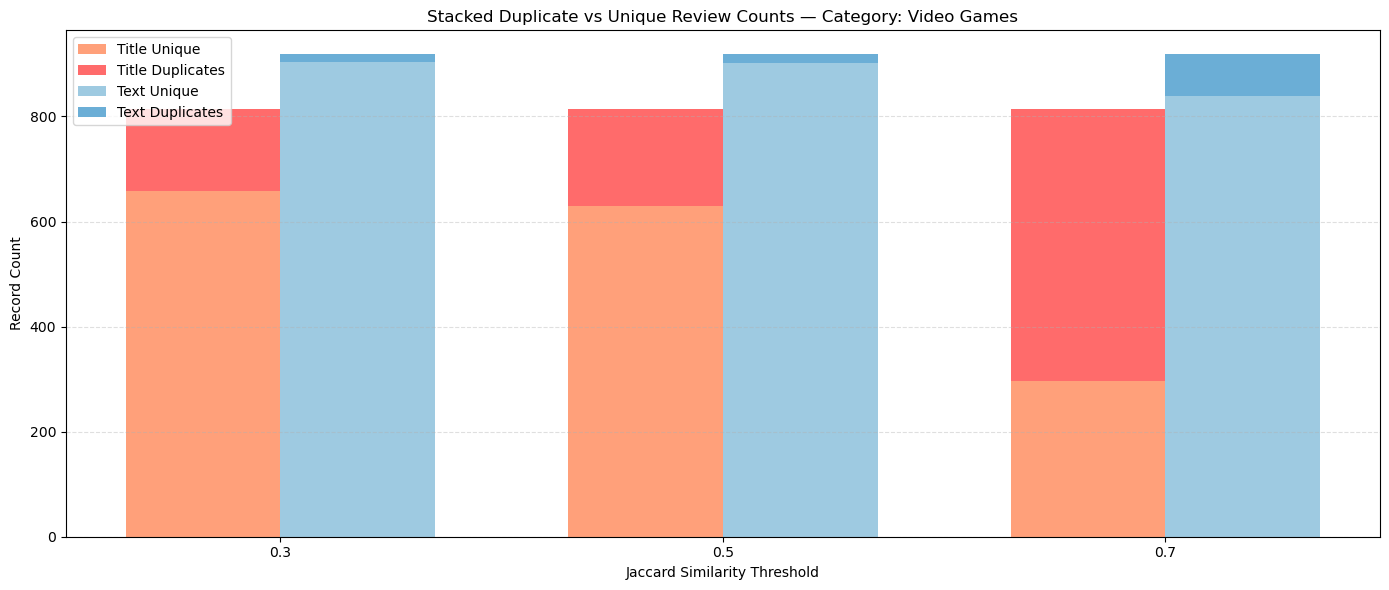

In [30]:
thresholds = ["0.3", "0.5", "0.7"]

title_dups = [title_dups_3_cnt, title_dups_5_cnt, title_dups_7_cnt]
title_unique = [title_unique_3, title_unique_5, title_unique_7]

text_dups = [text_dups_3_cnt, text_dups_5_cnt, text_dups_7_cnt]
text_unique = [text_unique_3, text_unique_5, text_unique_7]

plt.figure(figsize=(14,6))

x = np.arange(len(thresholds))
width = 0.35

# TITLE STACK 
plt.bar(
    x - width/2,
    title_unique,
    width,
    label="Title Unique",
    color="#FFA07A"
)

plt.bar(
    x - width/2,
    title_dups,
    width,
    bottom=title_unique,
    label="Title Duplicates",
    color="#FF6B6B"
)

# TEXT STACK
plt.bar(
    x + width/2,
    text_unique,
    width,
    label="Text Unique",
    color="#9ECAE1"
)

plt.bar(
    x + width/2,
    text_dups,
    width,
    bottom=text_unique,
    label="Text Duplicates",
    color="#6BAED6"
)

plt.xticks(x, thresholds)
plt.xlabel("Jaccard Similarity Threshold")
plt.ylabel("Record Count")
plt.title(f"Stacked Duplicate vs Unique Review Counts — Category: {category}")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.legend()
plt.tight_layout()

plt.show()

### Top 5 Products

In [31]:
top5_products = (
    df_cat.groupBy("parent_asin")
          .agg(F.count("*").alias("review_count"))
          .orderBy(F.col("review_count").desc())
          .limit(5)
          .select("parent_asin")
          .rdd.flatMap(lambda x: x)
          .collect()
)

print("Top 5 Products by Review Count:", top5_products)

Top 5 Products by Review Count: ['B08FYC9DQL', 'B07RFTRFPZ', 'B0BZ8DMFMM', 'B0851CKX2H', 'B0BTX52WS7']


In [32]:
results_title_per_product = {}

for asin in top5_products:

    df_prod = df_cat.filter(F.col("parent_asin") == asin)

    # 1. CLEAN + TOKENIZE TITLE
    df_title = df_prod.select("title")
    df_title = df_title.withColumn(
        "clean_title",
        F.regexp_replace("title", r"[\p{P}\p{C}]", "")
    )

    df_title = df_title.withColumn("title_words_raw", split("clean_title", " "))

    df_title = df_title.withColumn(
        "title_clean_words",
        F.expr("filter(title_words_raw, w -> length(w) >= 3)")
    )

    title_remover = StopWordsRemover(
        inputCol="title_clean_words",
        outputCol="title_filtered_words"
    )
    df_title = title_remover.transform(df_title)

    # Unique product-specific ID
    df_title = df_title.withColumn(
        "title_id",
        F.concat(F.lit(str(asin) + "_"), monotonically_increasing_id())
    )

    df_title = df_title.select("title_id", "title", "title_filtered_words")
    df_title = df_title.filter(F.size("title_filtered_words") > 0)

    # 2. VECTORIZER
    title_vectorizer = CountVectorizer(
        inputCol="title_filtered_words",
        outputCol="title_features",
        minDF=1.0
    )
    title_vec_model = title_vectorizer.fit(df_title)
    df_title_vec = title_vec_model.transform(df_title)
    df_title_vec = df_title_vec.withColumn(
        "title_arr",
        vector_to_array("title_features")
    )
    df_title_vec = df_title_vec.filter(
        F.expr("array_max(title_arr) > 0")
    )


    # 3. MINHASH LSH
    title_mh = MinHashLSH(
        inputCol="title_features",
        outputCol="title_hashes",
        numHashTables=5
    )
    title_mh_model = title_mh.fit(df_title_vec)
    df_title_hashed = title_mh_model.transform(df_title_vec).cache()

    # 4. DUPLICATE COUNTS
    def get_dups(th):
        return (
            title_mh_model
                .approxSimilarityJoin(df_title_hashed, df_title_hashed, th)
                .filter("datasetA.title_id < datasetB.title_id")
        )

    dups_03 = get_dups(0.3)
    dups_05 = get_dups(0.5)
    dups_07 = get_dups(0.7)

    total_titles = df_title_hashed.count()
    cnt_03 = dups_03.select("datasetA.title_id").distinct().count()
    cnt_05 = dups_05.select("datasetA.title_id").distinct().count()
    cnt_07 = dups_07.select("datasetA.title_id").distinct().count()

    results_title_per_product[asin] = {
        "total": total_titles,
        "dup_0.3": cnt_03,
        "dup_0.5": cnt_05,
        "dup_0.7": cnt_07
    }

    print(f"\n PRODUCT {asin}")
    print(f"Total titles: {total_titles}")
    print(f"Duplicates @0.3: {cnt_03}")
    print(f"Duplicates @0.5: {cnt_05}")
    print(f"Duplicates @0.7: {cnt_07}")

25/12/08 05:36:52 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:36:54 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:36:56 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B08FYC9DQL
Total titles: 168
Duplicates @0.3: 18
Duplicates @0.5: 21
Duplicates @0.7: 88


25/12/08 05:38:10 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:38:12 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:38:13 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B07RFTRFPZ
Total titles: 192
Duplicates @0.3: 32
Duplicates @0.5: 39
Duplicates @0.7: 110


25/12/08 05:39:22 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:39:23 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:39:25 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0BZ8DMFMM
Total titles: 58
Duplicates @0.3: 9
Duplicates @0.5: 11
Duplicates @0.7: 32


25/12/08 05:40:33 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:40:34 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:40:36 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0851CKX2H
Total titles: 24
Duplicates @0.3: 5
Duplicates @0.5: 5
Duplicates @0.7: 14


25/12/08 05:41:45 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:41:46 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:41:48 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0BTX52WS7
Total titles: 4
Duplicates @0.3: 0
Duplicates @0.5: 0
Duplicates @0.7: 1


In [33]:
results_text_per_product = {}

for asin in top5_products:

    df_prod = df_cat.filter(F.col("parent_asin") == asin)

    # 1. CLEAN + TOKENIZE TEXT
    df_text = df_prod.select("text")

    df_text = df_text.withColumn(
        "clean_text",
        F.regexp_replace("text", r"[\p{P}\p{C}]", "")
    )

    df_text = df_text.withColumn("text_words_raw", split("clean_text", " "))

    df_text = df_text.withColumn(
        "text_clean_words",
        F.expr("filter(text_words_raw, w -> length(w) >= 3)")
    )

    text_remover = StopWordsRemover(
        inputCol="text_clean_words",
        outputCol="text_filtered_words"
    )
    df_text = text_remover.transform(df_text)

    # UNIQUE ID PER PRODUCT
    df_text = df_text.withColumn(
        "text_id",
        F.concat(F.lit(str(asin) + "_"), monotonically_increasing_id())
    )

    df_text = df_text.select("text_id", "text", "text_filtered_words")
    df_text = df_text.filter(F.size("text_filtered_words") > 0)

    # 2. VECTORIZER
    text_vectorizer = CountVectorizer(
        inputCol="text_filtered_words",
        outputCol="text_features",
        minDF=1.0
    )
    text_vec_model = text_vectorizer.fit(df_text)
    df_text_vec = text_vec_model.transform(df_text)
    df_text_vec = df_text_vec.withColumn(
        "text_arr",
        vector_to_array("text_features")
    )
    df_text_vec = df_text_vec.filter(
        F.expr("array_max(text_arr) > 0")
    )

    # 3. MINHASH LSH
    text_mh = MinHashLSH(
        inputCol="text_features",
        outputCol="text_hashes",
        numHashTables=5
    )
    text_mh_model = text_mh.fit(df_text_vec)
    df_text_hashed = text_mh_model.transform(df_text_vec).cache()

    # 4. DUPLICATE COUNTS FOR THRESHOLDS
    def get_dups(th):
        return (
            text_mh_model
                .approxSimilarityJoin(df_text_hashed, df_text_hashed, th)
                .filter("datasetA.text_id < datasetB.text_id")
        )

    dups_03 = get_dups(0.3)
    dups_05 = get_dups(0.5)
    dups_07 = get_dups(0.7)

    total_texts = df_text_hashed.count()

    cnt_03 = dups_03.select("datasetA.text_id").distinct().count()
    cnt_05 = dups_05.select("datasetA.text_id").distinct().count()
    cnt_07 = dups_07.select("datasetA.text_id").distinct().count()

    results_text_per_product[asin] = {
        "total": total_texts,
        "dup_0.3": cnt_03,
        "dup_0.5": cnt_05,
        "dup_0.7": cnt_07
    }

    print(f"\n PRODUCT {asin}")
    print(f"Total texts: {total_texts}")
    print(f"Duplicates @0.3: {cnt_03}")
    print(f"Duplicates @0.5: {cnt_05}")
    print(f"Duplicates @0.7: {cnt_07}")

25/12/08 05:42:59 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:43:00 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:43:02 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B08FYC9DQL
Total texts: 238
Duplicates @0.3: 3
Duplicates @0.5: 4
Duplicates @0.7: 11


25/12/08 05:43:58 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:43:59 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:44:00 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B07RFTRFPZ
Total texts: 216
Duplicates @0.3: 2
Duplicates @0.5: 2
Duplicates @0.7: 13


25/12/08 05:45:05 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:45:07 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:45:08 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0BZ8DMFMM
Total texts: 63
Duplicates @0.3: 0
Duplicates @0.5: 0
Duplicates @0.7: 7


25/12/08 05:46:05 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:46:06 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:46:07 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0851CKX2H
Total texts: 40
Duplicates @0.3: 0
Duplicates @0.5: 1
Duplicates @0.7: 4


25/12/08 05:47:00 INFO PlanChangeLogger:                                        
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:47:01 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.

25/12/08 05:47:02 INFO PlanChangeLogger: 
 Dataproc Rule org.apache.spark.sql.catalyst.optimizer.google.ConvertToLeftSemiJoin effective 1 times.




 PRODUCT B0BTX52WS7
Total texts: 14
Duplicates @0.3: 0
Duplicates @0.5: 0
Duplicates @0.7: 0


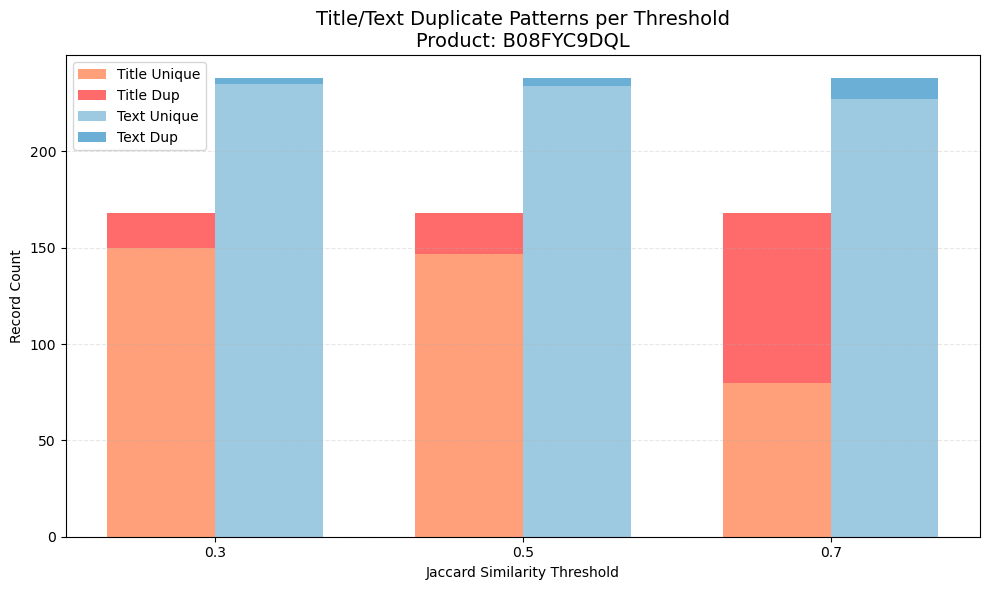

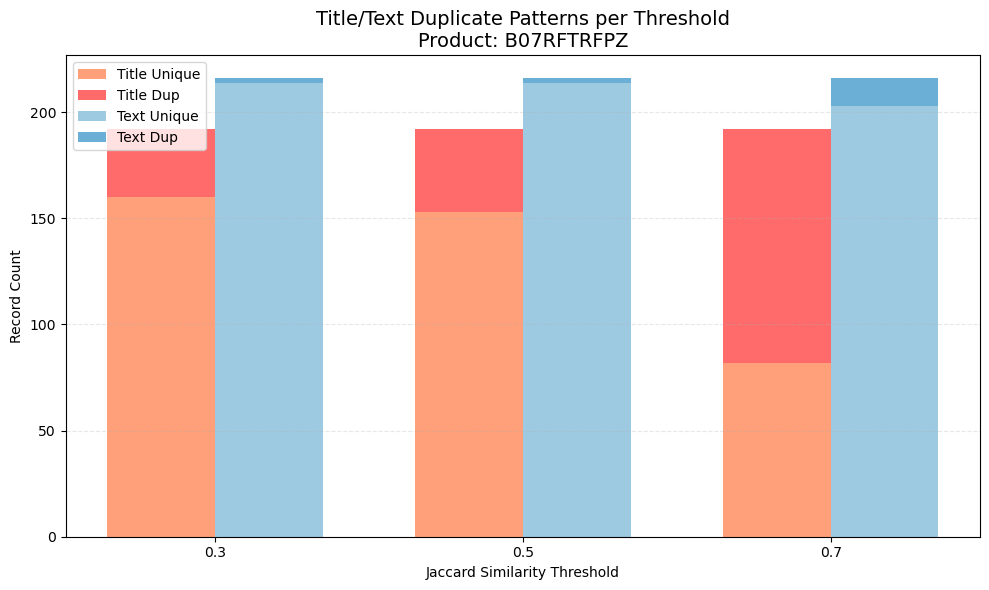

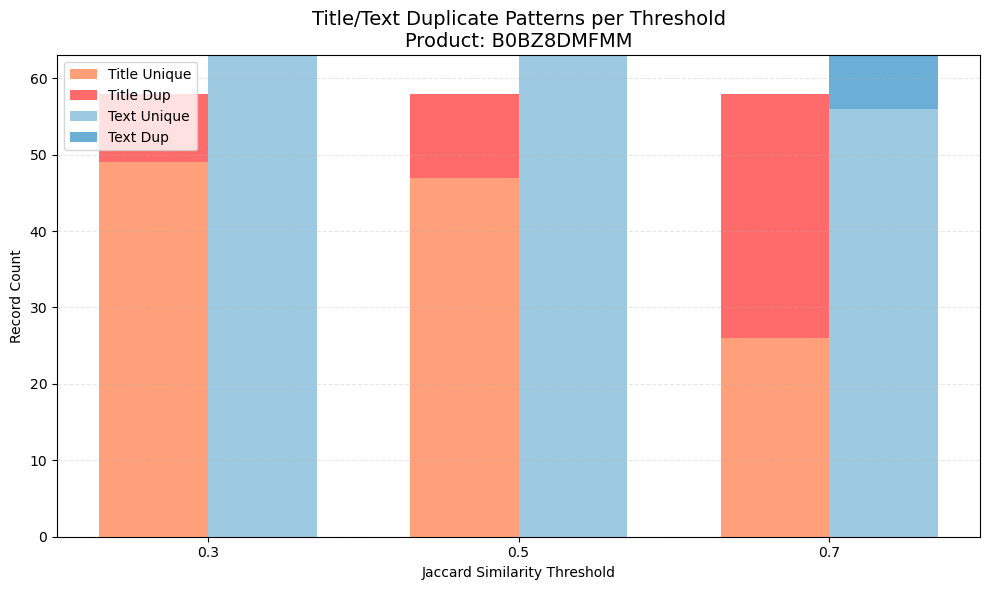

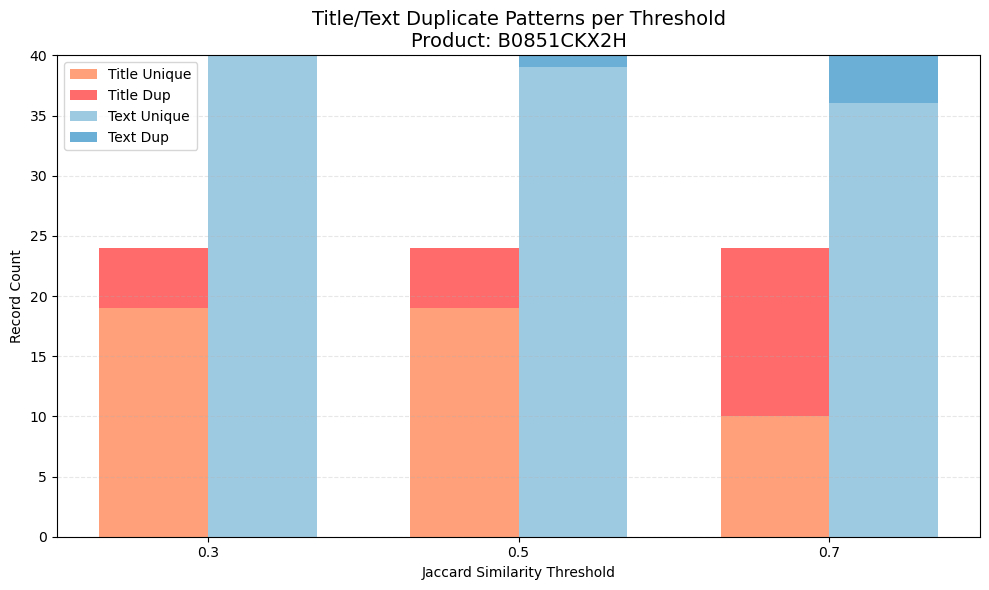

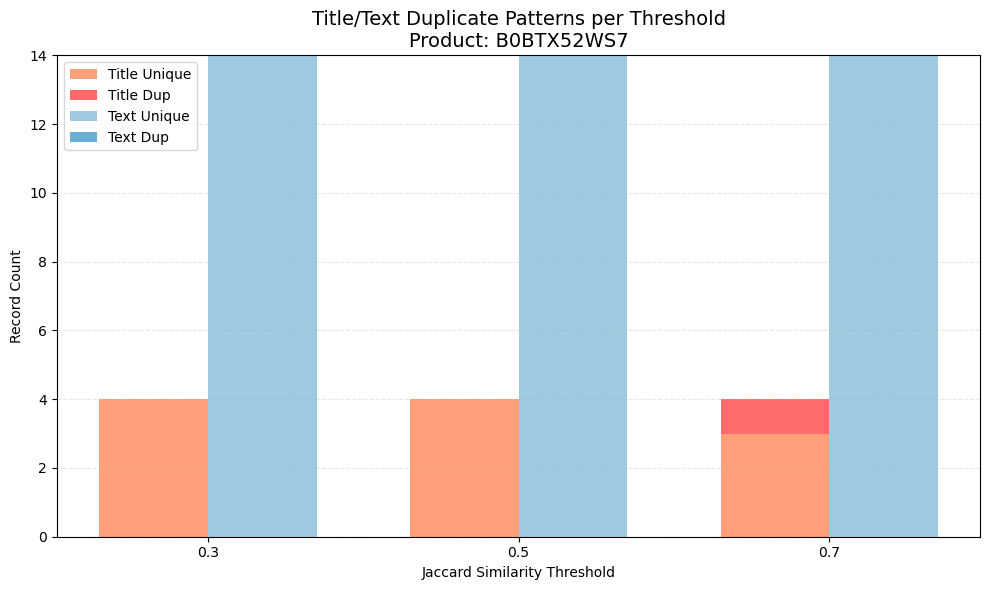

In [34]:
threshold_labels = ["0.3", "0.5", "0.7"]

for asin in top5_products:

    # Extract title duplicate + unique counts
    title_dup = [
        results_title_per_product[asin]["dup_0.3"],
        results_title_per_product[asin]["dup_0.5"],
        results_title_per_product[asin]["dup_0.7"]
    ]

    title_total = results_title_per_product[asin]["total"]
    title_unique = [title_total - d for d in title_dup]

    # Extract text duplicate + unique counts
    text_dup = [
        results_text_per_product[asin]["dup_0.3"],
        results_text_per_product[asin]["dup_0.5"],
        results_text_per_product[asin]["dup_0.7"]
    ]

    text_total = results_text_per_product[asin]["total"]
    text_unique = [text_total - d for d in text_dup]

    # X positions
    x = np.arange(len(threshold_labels))
    width = 0.35

    plt.figure(figsize=(10,6))

    # TITLE STACKED BAR 
    plt.bar(
        x - width/2,
        title_unique,
        width,
        label="Title Unique",
        color="#FFA07A"
    )
    plt.bar(
        x - width/2,
        title_dup,
        width,
        bottom=title_unique,
        label="Title Dup",
        color="#FF6B6B"
    )

    # TEXT STACKED BAR
    plt.bar(
        x + width/2,
        text_unique,
        width,
        label="Text Unique",
        color="#9ECAE1"
    )
    plt.bar(
        x + width/2,
        text_dup,
        width,
        bottom=text_unique,
        label="Text Dup",
        color="#6BAED6"
    )

    # Formatting
    plt.title(f"Title/Text Duplicate Patterns per Threshold\nProduct: {asin}", fontsize=14)
    plt.xticks(x, threshold_labels)
    plt.xlabel("Jaccard Similarity Threshold")
    plt.ylabel("Record Count")
    plt.grid(axis="y", linestyle="--", alpha=0.3)
    plt.legend()
    plt.tight_layout()

    plt.show()